In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D


In [2]:
# Load CIFAR-10
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize: 0 to 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Grayscale banao (INPUT)
def to_grayscale(images):
    gray = []
    for img in images:
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        g = np.expand_dims(g, axis=-1)
        gray.append(g)
    return np.array(gray)

x_train_gray = to_grayscale(x_train)
x_test_gray = to_grayscale(x_test)

print("Input shape:", x_train_gray.shape)
print("Output shape:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Input shape: (50000, 32, 32, 1)
Output shape: (50000, 32, 32, 3)


In [3]:
input_img = Input(shape=(32, 32, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,075 (293.26 KB)

 Trainable params: 75,075 (293.26 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = autoencoder.fit(
    x_train_gray, x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_gray, x_test),
    shuffle=True
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - loss: 0.0151 - val_loss: 0.0107
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - loss: 0.0101 - val_loss: 0.0096
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0094 - val_loss: 0.0091
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0090 - val_loss: 0.0088
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0082 - val_loss: 0.0081
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0080 - val_loss: 0.0079
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - loss: 0.0077 - val_loss: 0.0074
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - loss: 0.0075 - val_loss: 0.0074
Epoch 12/20
391/391 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


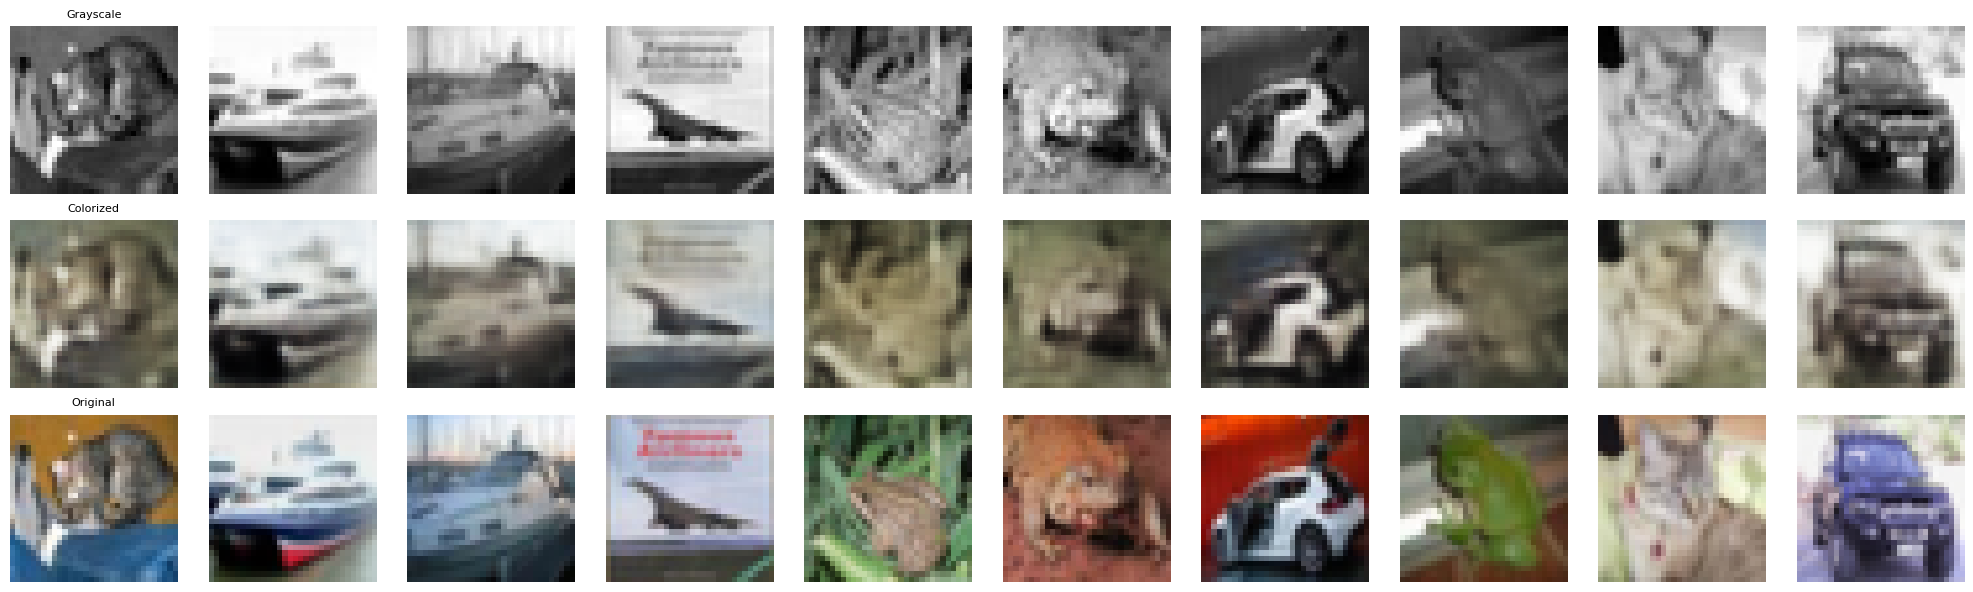

In [8]:
# Predict
predictions = autoencoder.predict(x_test_gray[:10])

# Plot
fig, axes = plt.subplots(3, 10, figsize=(20, 6))

for i in range(10):
    # Grayscale input
    axes[0, i].imshow(x_test_gray[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    
    # Colorized output
    axes[1, i].imshow(predictions[i])
    axes[1, i].axis('off')
    
    # Original color
    axes[2, i].imshow(x_test[i])
    axes[2, i].axis('off')

axes[0, 0].set_title('Grayscale', fontsize=8)
axes[1, 0].set_title('Colorized', fontsize=8)
axes[2, 0].set_title('Original', fontsize=8)

plt.tight_layout()
plt.show()


In [6]:
autoencoder.save('image_colorization_model.h5')
print("Model saved!")


Model saved!


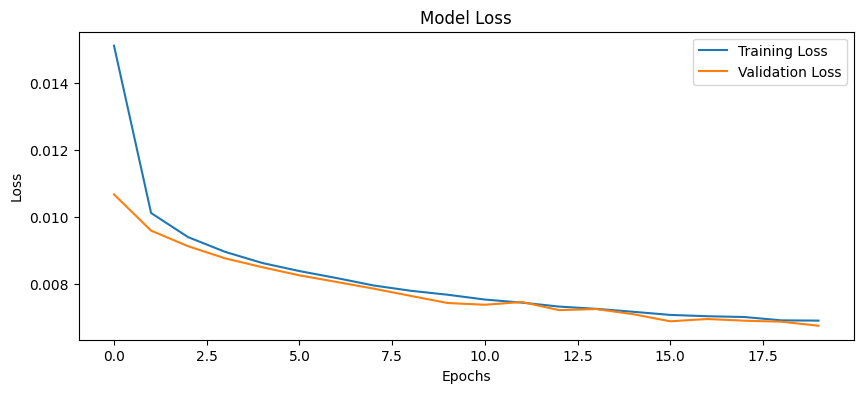

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()